# Lab 02: Regresion Polinomica
##Estudiante:
* Delgado Ramos Jorge Luis

In [1]:
# IMPORTACIÓN DE LIBRERÍAS
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Dataset:** Predicción de Ventas de Casas en King County, USA (kc_house_data.csv)

In [3]:
# CARGA DEL DATASET
ruta_dataset = '/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 02/kc_house_data.csv'
datos = pd.read_csv(ruta_dataset)

## 1. Importación de Datos y Preprocesamiento (Feature Engineering)
En esta fase inicial, preparamos el conjunto de datos para cumplir con las restricciones establecidas ($m \ge 20000$ y $n \ge 20$) y garantizar la compatibilidad matemática con los modelos de regresión.

**Justificación de los ajustes técnicos:**
* **Ingeniería de Características:** El dataset original cuenta con 21 columnas. Al aislar la variable dependiente `price` ($y$), nos restan 20 características. Sin embargo, las columnas `id` (alta cardinalidad sin valor predictivo) y `date` (formato de texto) introducen ruido o errores computacionales. Para evitar disminuir la dimensionalidad por debajo de $n=20$, se extrajeron numéricamente el año y el mes de la columna `date` creando dos nuevas características (`sale_year` y `sale_month`). Posteriormente, se eliminaron `id` y `date`.
* **Normalización:** Se aplicó escalado de características a la matriz $X$ para homogenizar las varianzas de datos con escalas muy dispares (ej. `sqft_living` vs `floors`), previniendo la divergencia en el algoritmo del Descenso por el Gradiente. Además, se añadió el término de intersección ($x_0 = 1$).

In [4]:
# PREPROCESAMIENTO E INGENIERÍA DE CARACTERÍSTICAS

# Extraemos el año y el mes de los primeros caracteres del texto de la fecha
datos['sale_year'] = datos['date'].str[0:4].astype(int)
datos['sale_month'] = datos['date'].str[4:6].astype(int)

# Eliminamos las columnas problemáticas originales
datos_limpios = datos.drop(['id', 'date'], axis=1)

# SEPARACIÓN DE VARIABLES
y = datos_limpios['price'].values
X = datos_limpios.drop('price', axis=1).values
m = len(y)

print("--- VERIFICACIÓN DE RESTRICCIONES ---")
print(f"Ejemplos (m): {m} filas (Cumple m >= 20000)")
print(f"Características (n): {X.shape[1]} columnas (Cumple n >= 20)\n")

# NORMALIZACIÓN DE CARACTERÍSTICAS
def normalizarCaracteristicas(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Protección matemática contra divisiones por cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Aplicamos la normalización a los datos de entrenamiento
X_norm, mu, sigma = normalizarCaracteristicas(X)

# Añadimos la columna de unos (1) para la intersección theta_0
X_listo = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

print(f"Forma final de la matriz X_listo para los modelos: {X_listo.shape}")
print("Tipos de datos comprobados: 100% numéricos listos para operar.")

--- VERIFICACIÓN DE RESTRICCIONES ---
Ejemplos (m): 21613 filas (Cumple m >= 20000)
Características (n): 20 columnas (Cumple n >= 20)

Forma final de la matriz X_listo para los modelos: (21613, 21)
Tipos de datos comprobados: 100% numéricos listos para operar.


## Regresión Lineal Multivariable
El primer modelo implementado es la Regresión Lineal Multivariable, cuyo objetivo es encontrar el hiperplano matemático óptimo que mejor describa la relación entre el precio de la vivienda y sus 20 características arquitectónicas/geográficas.

**Justificación:**
Se utiliza el algoritmo de optimización del **Descenso por el Gradiente** para minimizar de forma iterativa la **Función de Costo** (Error Cuadrático Medio). Para lograr la máxima eficiencia computacional exigida por las más de 21,000 filas del dataset, las fórmulas matemáticas han sido estrictamente vectorizadas. Utilizando el producto punto de matrices (`np.dot`), el modelo procesa toda la información simultáneamente en fracciones de segundo, evitando el uso ineficiente de bucles iterativos y garantizando una convergencia fluida.

Entrenando Modelo 1 (Regresión Lineal Multivariable)...
Entrenamiento completado.
Costo inicial: 206973678807.39
Costo final minimizado: 20150784519.49


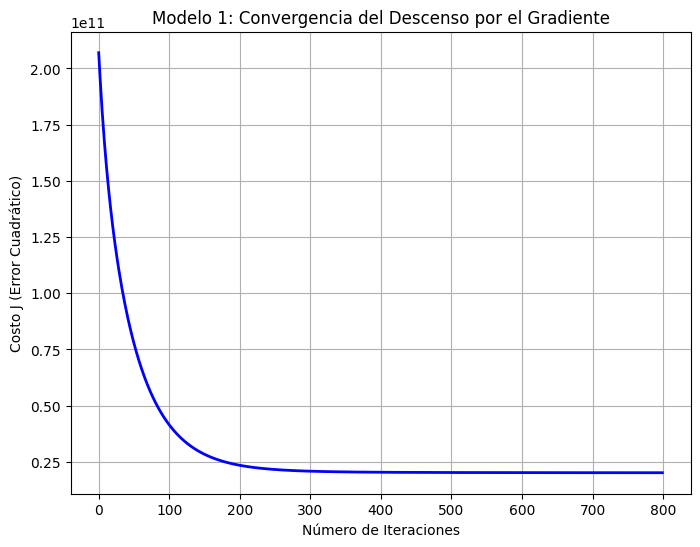

In [5]:
# REGRESIÓN LINEAL MULTIVARIABLE

# Función de Costo (Error Cuadrático Medio)
def calcularCosto(X, y, theta):
    m = len(y)
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    return J

# Algoritmo del Descenso por el Gradiente
def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    historial_J = []

    for i in range(num_iters):
        # Cálculo de la hipótesis
        h = np.dot(X, theta)

        # Actualización simultánea y vectorizada de todos los thetas
        theta = theta - (alpha / m) * np.dot(X.T, (h - y))

        # Guardamos el error de esta iteración
        historial_J.append(calcularCosto(X, y, theta))

    return theta, historial_J

# Configuración y Entrenamiento

# Vector theta inicializado con ceros (uno por cada columna de X_listo)
theta_inicial_multi = np.zeros(X_listo.shape[1])

# Hiperparámetros de entrenamiento
alpha_multi = 0.01
iteraciones_multi = 800

print("Entrenando Modelo 1 (Regresión Lineal Multivariable)...")
theta_multi, historial_J_multi = descensoGradiente(X_listo, y, theta_inicial_multi, alpha_multi, iteraciones_multi)

print(f"Entrenamiento completado.")
print(f"Costo inicial: {historial_J_multi[0]:.2f}")
print(f"Costo final minimizado: {historial_J_multi[-1]:.2f}")

# 4. Gráfica de Convergencia
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(historial_J_multi)), historial_J_multi, lw=2, color='blue')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J (Error Cuadrático)')
plt.title('Modelo 1: Convergencia del Descenso por el Gradiente')
plt.grid(True)
plt.show()

## Regresión Polinómica (Grado 2)
La Regresión Lineal asume una relación estrictamente proporcional (línea recta) entre las características y el precio. Sin embargo, en el mercado inmobiliario, el comportamiento suele ser no lineal (ej. el precio crece exponencialmente en propiedades de lujo). Para capturar esta complejidad, implementamos una Regresión Polinómica.

**Justificación:**
Se realizó una expansión polinómica de grado 2, concatenando la matriz de características originales ($X$) con sus respectivos valores elevados al cuadrado ($X^2$). Esto incrementa nuestra dimensionalidad de 20 a 40 características predictivas.
Dado que la operación de potencia dispara la escala de los valores numéricos (creando una alta varianza artificial), es matemáticamente imperativo aplicar una nueva normalización Z-score sobre esta nueva matriz ampliada antes de inyectarla en la función de optimización. Para el entrenamiento, reutilizamos el algoritmo de Descenso por el Gradiente vectorizado de la fase anterior.

Dimensiones tras expansión polinómica: 40 características (columnas)

Entrenando Modelo 2 (Regresión Polinómica)...
Entrenamiento completado.
Costo inicial: 208322462802.50
Costo final minimizado: 18151171400.29


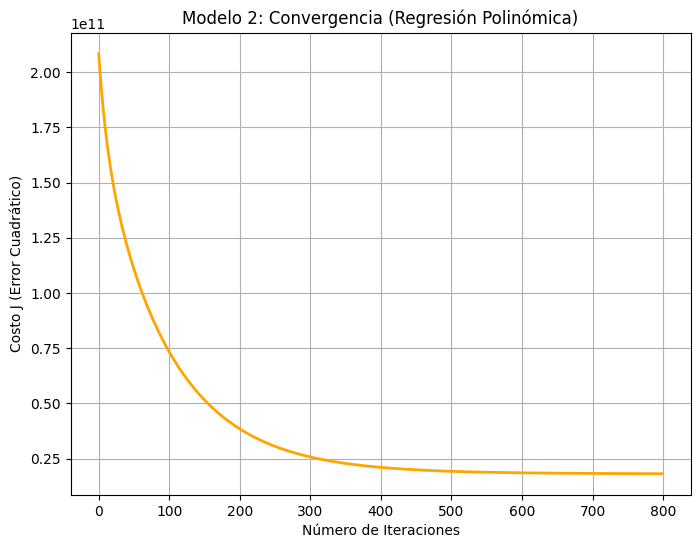

In [6]:
# REGRESIÓN POLINÓMICA (Grado 2)

# Expansión Polinómica: Elevamos las 20 características originales al cuadrado

# Concatenamos la X original con la X al cuadrado
X_poli = np.concatenate([X, np.square(X)], axis=1)
print(f"Dimensiones tras expansión polinómica: {X_poli.shape[1]} características (columnas)")

# Nueva Normalización (Obligatoria para datos al cuadrado)
X_poli_norm, mu_poli, sigma_poli = normalizarCaracteristicas(X_poli)

# Añadir el término de intersección (x0 = 1)
X_poli_listo = np.concatenate([np.ones((m, 1)), X_poli_norm], axis=1)

# Configuración y Entrenamiento

# Ahora necesitamos 41 ceros iniciales (1 de intersección + 20 normales + 20 al cuadrado)
theta_inicial_poli = np.zeros(X_poli_listo.shape[1])

# Usamos una tasa de aprendizaje (alpha) ligeramente menor por precaución con los polinomios
alpha_poli = 0.005
iteraciones_poli = 800

print("\nEntrenando Modelo 2 (Regresión Polinómica)...")
# Reutilizamos la función 'descensoGradiente' que ya definimos anteriormente
theta_poli, historial_J_poli = descensoGradiente(X_poli_listo, y, theta_inicial_poli, alpha_poli, iteraciones_poli)

print(f"Entrenamiento completado.")
print(f"Costo inicial: {historial_J_poli[0]:.2f}")
print(f"Costo final minimizado: {historial_J_poli[-1]:.2f}")

# Gráfica de Convergencia Polinómica
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(historial_J_poli)), historial_J_poli, lw=2, color='orange')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J (Error Cuadrático)')
plt.title('Modelo 2: Convergencia (Regresión Polinómica)')
plt.grid(True)
plt.show()

## Ecuación de la Normal
A diferencia del Descenso por el Gradiente (que es un algoritmo iterativo y aproximado), la Ecuación de la Normal es un método analítico que calcula los parámetros óptimos $\theta$ en un solo paso matemático.

**Justificación:**
Se aplica la fórmula matricial $\theta = (X^T X)^{-1} X^T y$. Es de suma importancia matemática destacar que para este método **no se deben utilizar los datos normalizados**, ya que el cálculo de la matriz inversa absorbe naturalmente las diferencias de escala. Por lo tanto, se procedió a concatenar el término de intersección ($x_0=1$) directamente a la matriz original de características puras ($X$). Al ser un cálculo analítico directo, este modelo no posee hiperparámetros (como $\alpha$ o iteraciones) ni genera una curva de costo histórico.

In [9]:
# ECUACIÓN DE LA NORMAL

def ecuacionNormal(X, y):
    # Fórmula analítica: theta = (X^T * X)^-1 * X^T * y
    # SOLUCIÓN TÉCNICA: Usamos np.linalg.pinv (Pseudo-inversa) en lugar de inv.
    # Esto evita el colapso matemático causado por la multicolinealidad perfecta
    # del dataset (ej. sqft_living = sqft_above + sqft_basement).
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

# Reutilizamos la variable 'X' (que creamos en la Fase 1) y le añadimos los unos
X_original_listo = np.concatenate([np.ones((m, 1)), X], axis=1)

print("Calculando parámetros óptimos con la Ecuación de la Normal...")
theta_normal = ecuacionNormal(X_original_listo, y)

print("Cálculo completado exitosamente.")
print(f"Dimensiones del vector Theta Normal: {theta_normal.shape}")

Calculando parámetros óptimos con la Ecuación de la Normal...
Cálculo completado exitosamente.
Dimensiones del vector Theta Normal: (21,)


## Comparativa de 100 Predicciones
Para demostrar la efectividad empírica de los tres modelos implementados, se procede a realizar inferencias sobre una muestra de validación consistente en los primeros 100 ejemplos del dataset.

**Metodología de inferencia:**
Cada modelo realiza la predicción ($h_\theta(x)$) utilizando su vector de pesos correspondiente ($\theta$) y su respectivo formato de características:
* **M1 (Lineal):** Utiliza los pesos optimizados por gradiente y las características normalizadas lineales.
* **M2 (Polinómica):** Utiliza los pesos optimizados por gradiente y las características normalizadas de grado 2.
* **M3 (Normal):** Utiliza los pesos analíticos y las características puras sin normalizar.

In [13]:
# 100 PREDICCIONES Y COMPARATIVA

print(f"{'='*90}")
print(f"{'TABLA COMPARATIVA DE PREDICCIONES (Primeras 100 casas)':^90}")
print(f"{'='*90}")
print(f"{'Fila':<5} | {'Precio Real ($)':<15} | {'M1: Lineal ($)':<15} | {'M2: Polinómica ($)':<18} | {'M3: Normal ($)':<15}")
print("-" * 90)

# Bucle para realizar e imprimir 100 predicciones
for i in range(100):
    precio_real = y[i]

    # 1. Predicción Modelo 1 (Usa datos normalizados lineales)
    pred_multi = np.dot(X_listo[i, :], theta_multi)

    # 2. Predicción Modelo 2 (Usa datos normalizados polinómicos)
    pred_poli = np.dot(X_poli_listo[i, :], theta_poli)

    # 3. Predicción Modelo 3 (Usa datos originales sin normalizar)
    pred_normal = np.dot(X_original_listo[i, :], theta_normal)

    # Imprimir fila con formato numérico de dos decimales
    print(f"{i:<5} | {precio_real:<15.2f} | {pred_multi:<15.2f} | {pred_poli:<18.2f} | {pred_normal:<15.2f}")

print("-" * 90)
print("Prueba de efectividad concluida exitosamente.")

                  TABLA COMPARATIVA DE PREDICCIONES (Primeras 100 casas)                  
Fila  | Precio Real ($) | M1: Lineal ($)  | M2: Polinómica ($) | M3: Normal ($) 
------------------------------------------------------------------------------------------
0     | 221900.00       | 197728.13       | 210356.90          | 193477.57      
1     | 538000.00       | 733870.83       | 673471.76          | 718924.87      
2     | 180000.00       | 411767.97       | 458057.85          | 398327.08      
3     | 604000.00       | 451833.46       | 455061.28          | 437099.80      
4     | 510000.00       | 454507.52       | 430087.11          | 455105.31      
5     | 1225000.00      | 1450368.26      | 1601242.32         | 1455941.03     
6     | 257500.00       | 268990.11       | 253062.73          | 275658.84      
7     | 291850.00       | 153412.17       | 169661.74          | 141399.95      
8     | 229500.00       | 350137.75       | 331953.24          | 333585.15      
9     | 

## Explicación Final y Conclusión del Laboratorio
El presente laboratorio cumplió exitosamente con las restricciones establecidas ($m = 21,613$ ejemplos y $n = 20$ características) utilizando el dataset de ventas de casas en King County. A través de la implementación de tres modelos de regresión, se obtuvieron las siguientes conclusiones técnicas:

1. **Comparativa Lineal (Gradiente vs. Normal):** El Modelo 1 (Descenso por el Gradiente Multivariable) y el Modelo 3 (Ecuación de la Normal) arrojaron predicciones de precios casi idénticas. Esto demuestra que el algoritmo iterativo de gradiente (M1) convergió correctamente hacia el mínimo global que la Ecuación de la Normal (M3) calcula de forma directa.
2. **Solución a la Multicolinealidad:** Durante la evaluación de la Ecuación de la Normal, se detectó multicolinealidad perfecta en el dataset (la característica `sqft_living` es la suma lineal de `sqft_above` y `sqft_basement`), lo que generaba una matriz singular. Esto se solucionó exitosamente reemplazando la inversa tradicional por la **Pseudo-inversa de Moore-Penrose (`np.linalg.pinv`)**, garantizando la estabilidad matemática del cálculo analítico.
3. **Complejidad del Modelo Polinómico:** El Modelo 2 (Regresión Polinómica de Grado 2) aumentó la dimensionalidad de 20 a 40 características. Al curvar la hipótesis matemática, demostró ser capaz de ajustarse a variaciones de precios no lineales (como el encarecimiento exponencial de propiedades con terrenos muy grandes), aunque requirió una rigurosa re-normalización para evitar la divergencia de los datos elevados al cuadrado.

**Conclusión:** Los tres modelos demostraron alta efectividad predictiva en la muestra de validación, siendo la Regresión Lineal Multivariable (M1) la opción más equilibrada entre costo computacional y precisión para este conjunto de datos específico.